In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score

# **Data Preparation**

In [ ]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


In [ ]:
df.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


In [ ]:
''' Feature Engineering '''

df['glucose_hba1c_ratio'] = df['blood_glucose_level'] / (df['HbA1c_level'] + 1e-6)
df['bmi_age_ratio'] = df['bmi'] / (df['age'] + 1e-6)
df['bmi_squared'] = df['bmi'] ** 2
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,glucose_hba1c_ratio,bmi_age_ratio,bmi_squared
0,Female,80.0,0,1,never,25.19,6.6,140,0,21.212118,0.314875,634.5361
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,12.121210,0.505926,746.3824
2,Male,28.0,0,0,never,27.32,5.7,158,0,27.719293,0.975714,746.3824
3,Female,36.0,0,0,current,23.45,5.0,155,0,30.999994,0.651389,549.9025
4,Male,76.0,1,1,current,20.14,4.8,155,0,32.291660,0.265000,405.6196
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0,14.516127,0.341500,746.3824
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0,15.384613,8.684996,301.7169
99997,Male,66.0,0,0,former,27.83,5.7,155,0,27.192978,0.421667,774.5089
99998,Female,24.0,0,0,never,35.42,4.0,100,0,24.999994,1.475833,1254.5764


In [ ]:
''' Encoding '''

df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)
df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,glucose_hba1c_ratio,bmi_age_ratio,bmi_squared,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,21.212118,0.314875,634.5361,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,12.121210,0.505926,746.3824,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,27.719293,0.975714,746.3824,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,30.999994,0.651389,549.9025,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,32.291660,0.265000,405.6196,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90,0,14.516127,0.341500,746.3824,False,False,False,False,False,False,False
99996,2.0,0,0,17.37,6.5,100,0,15.384613,8.684996,301.7169,False,False,False,False,False,False,False
99997,66.0,0,0,27.83,5.7,155,0,27.192978,0.421667,774.5089,True,False,False,False,True,False,False
99998,24.0,0,0,35.42,4.0,100,0,24.999994,1.475833,1254.5764,False,False,False,False,False,True,False


In [ ]:
''' Splitting and Scaling '''

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])
print(X_train[num_cols])

            age       bmi  HbA1c_level  blood_glucose_level
75220  1.378720 -0.386474    -1.892451            -1.425157
48955  1.689866 -0.412172     0.162169             0.170591
44966 -0.177011 -0.452986    -1.425492             0.489740
13568 -0.710404 -1.278339    -0.491574            -0.934157
92727  0.845326 -0.788570    -0.958533            -1.302407
...         ...       ...          ...                  ...
6265   0.311933  0.854578     0.162169            -1.425157
54886 -1.199348  0.116900    -0.491574             0.514290
76820  0.000787 -0.179380     0.255561            -1.302407
860   -0.221460 -0.357753     0.629128             0.489740
15795 -0.843752  0.100272    -0.491574             0.514290

[80000 rows x 4 columns]


In [ ]:
''' Appling SMOTE to handle the class imbalance '''

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE - Training set shape:", X_train.shape)
print("After SMOTE - Training set shape:", X_train_balanced.shape)
print("\nClass distribution before SMOTE:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(y_train_balanced.value_counts())
print("\nSMOTE has balanced the classes!")

Before SMOTE - Training set shape: (80000, 16)
After SMOTE - Training set shape: (146416, 16)

Class distribution before SMOTE:
diabetes
0    73208
1     6792
Name: count, dtype: int64

Class distribution after SMOTE:
diabetes
0    73208
1    73208
Name: count, dtype: int64

SMOTE has balanced the classes!


# **Model implementation**

In [ ]:
''' Logistic Regression '''

log_reg = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
log_reg.fit(X_train_balanced, y_train_balanced)

y_pred_lr = log_reg.predict(X_test)
y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS\n")
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_lr))

LOGISTIC REGRESSION RESULTS


Accuracy: 0.9075

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     18292
           1       0.48      0.82      0.60      1708

    accuracy                           0.91     20000
   macro avg       0.73      0.87      0.78     20000
weighted avg       0.94      0.91      0.92     20000


Confusion Matrix:
[[16746  1546]
 [  304  1404]]

ROC-AUC Score: 0.9546977415806349


In [ ]:
''' Decision Tree '''

dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_classifier.fit(X_train_balanced, y_train_balanced)

y_pred_dt = dt_classifier.predict(X_test)
y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]

print("DECISION TREE RESULTS\n")
print("\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_dt))


DECISION TREE RESULTS


Accuracy: 0.9192

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     18292
           1       0.52      0.83      0.64      1708

    accuracy                           0.92     20000
   macro avg       0.75      0.88      0.80     20000
weighted avg       0.94      0.92      0.93     20000


Confusion Matrix:
[[16958  1334]
 [  282  1426]]

ROC-AUC Score: 0.9682559811663101


In [ ]:
''' Random Forest '''

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_classifier.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf_classifier.predict(X_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS\n")
print("\nAccuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))


RANDOM FOREST RESULTS


Accuracy: 0.92645

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18292
           1       0.54      0.85      0.66      1708

    accuracy                           0.93     20000
   macro avg       0.76      0.89      0.81     20000
weighted avg       0.95      0.93      0.93     20000


Confusion Matrix:
[[17080  1212]
 [  259  1449]]

ROC-AUC Score: 0.9728304845004612


In [ ]:
''' SVM (Linear) '''

print("SUPPORT VECTOR MACHINE (SVM) IMPLEMENTATION\n")

start_time = time.time()

svm_model = LinearSVC(C=1.0, random_state=42, max_iter=2000, dual=False)
svm_model.fit(X_train_balanced, y_train_balanced)

svm_calibrated = CalibratedClassifierCV(svm_model, cv=3)
svm_calibrated.fit(X_train_balanced, y_train_balanced)

training_time = time.time() - start_time

y_pred_svm = svm_calibrated.predict(X_test)
y_pred_proba_svm = svm_calibrated.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_svm))



SUPPORT VECTOR MACHINE (SVM) IMPLEMENTATION


Accuracy: 0.907

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.95     18292
           1       0.47      0.82      0.60      1708

    accuracy                           0.91     20000
   macro avg       0.73      0.87      0.77     20000
weighted avg       0.94      0.91      0.92     20000


Confusion Matrix:
[[16735  1557]
 [  303  1405]]

ROC-AUC Score: 0.9543302961686838


# **Model Optimization**
**Performing Hyperparameter tuning**

In [53]:
'''Tuning the Decision tree using Randomized Search'''


''' Defining parameters for Decision Tree '''
param_distributions_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

dt_random = DecisionTreeClassifier(random_state=42)

'''Perform Randomized Search with 3-fold cross-validation'''

randomized_search_dt = RandomizedSearchCV(
    estimator=dt_random,
    param_distributions=param_distributions_dt,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

start_time = time.time()
randomized_search_dt.fit(X_train_balanced, y_train_balanced)
training_time = time.time() - start_time

print("DECISION TREE - BEST HYPERPARAMETERS\n")
print(randomized_search_dt.best_params_)
print(f"\nBest Cross-Validation ROC-AUC Score: {randomized_search_dt.best_score_:.4f}")

best_dt = randomized_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
y_pred_proba_best_dt = best_dt.predict_proba(X_test)[:, 1]

print("OPTIMIZED DECISION TREE - TEST SET RESULTS\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_best_dt):.4f}")




Fitting 3 folds for each of 15 candidates, totalling 45 fits
DECISION TREE - BEST HYPERPARAMETERS

{'min_samples_split': 50, 'min_samples_leaf': 20, 'max_depth': None, 'criterion': 'gini'}

Best Cross-Validation ROC-AUC Score: 0.9879
OPTIMIZED DECISION TREE - TEST SET RESULTS

Accuracy: 0.9506

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18292
           1       0.69      0.76      0.72      1708

    accuracy                           0.95     20000
   macro avg       0.83      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000


ROC-AUC Score: 0.9516


In [54]:
''' Tuning the Random Forest using Randomized Search '''

''' Defining parameters for Random Forest '''
param_distributions_rf = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

rf_random = RandomForestClassifier(random_state=42, n_jobs=-1)

''' Perform Randomized Search with 3-fold cross-validation '''
randomized_search_rf = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_distributions_rf,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("RANDOM FOREST HYPERPARAMETER TUNING - RANDOMIZED SEARCH\n")
total_combinations = (len(param_distributions_rf['n_estimators']) *
                     len(param_distributions_rf['criterion']) *
                     len(param_distributions_rf['max_depth']) *
                     len(param_distributions_rf['min_samples_split']) *
                     len(param_distributions_rf['min_samples_leaf']))


start_time = time.time()
randomized_search_rf.fit(X_train_balanced, y_train_balanced)
training_time = time.time() - start_time

print("RANDOM FOREST - BEST HYPERPARAMETERS\n")
print(randomized_search_rf.best_params_)
print(f"\nBest Cross-Validation ROC-AUC Score: {randomized_search_rf.best_score_:.4f}")

best_rf = randomized_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("OPTIMIZED RANDOM FOREST - TEST SET RESULTS\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_best_rf):.4f}")




RANDOM FOREST HYPERPARAMETER TUNING - RANDOMIZED SEARCH

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RANDOM FOREST - BEST HYPERPARAMETERS

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': None, 'criterion': 'entropy'}

Best Cross-Validation ROC-AUC Score: 0.9964
OPTIMIZED RANDOM FOREST - TEST SET RESULTS

Accuracy: 0.9617

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18292
           1       0.79      0.75      0.77      1708

    accuracy                           0.96     20000
   macro avg       0.88      0.87      0.87     20000
weighted avg       0.96      0.96      0.96     20000


ROC-AUC Score: 0.9745


# **Model Comparison**

COMPREHENSIVE MODEL COMPARISON

                 Model  Accuracy       AUC
2        Random Forest   0.92645  0.972830
1        Decision Tree   0.91920  0.968256
0  Logistic Regression   0.90750  0.954698
3                  SVM   0.90700  0.954330


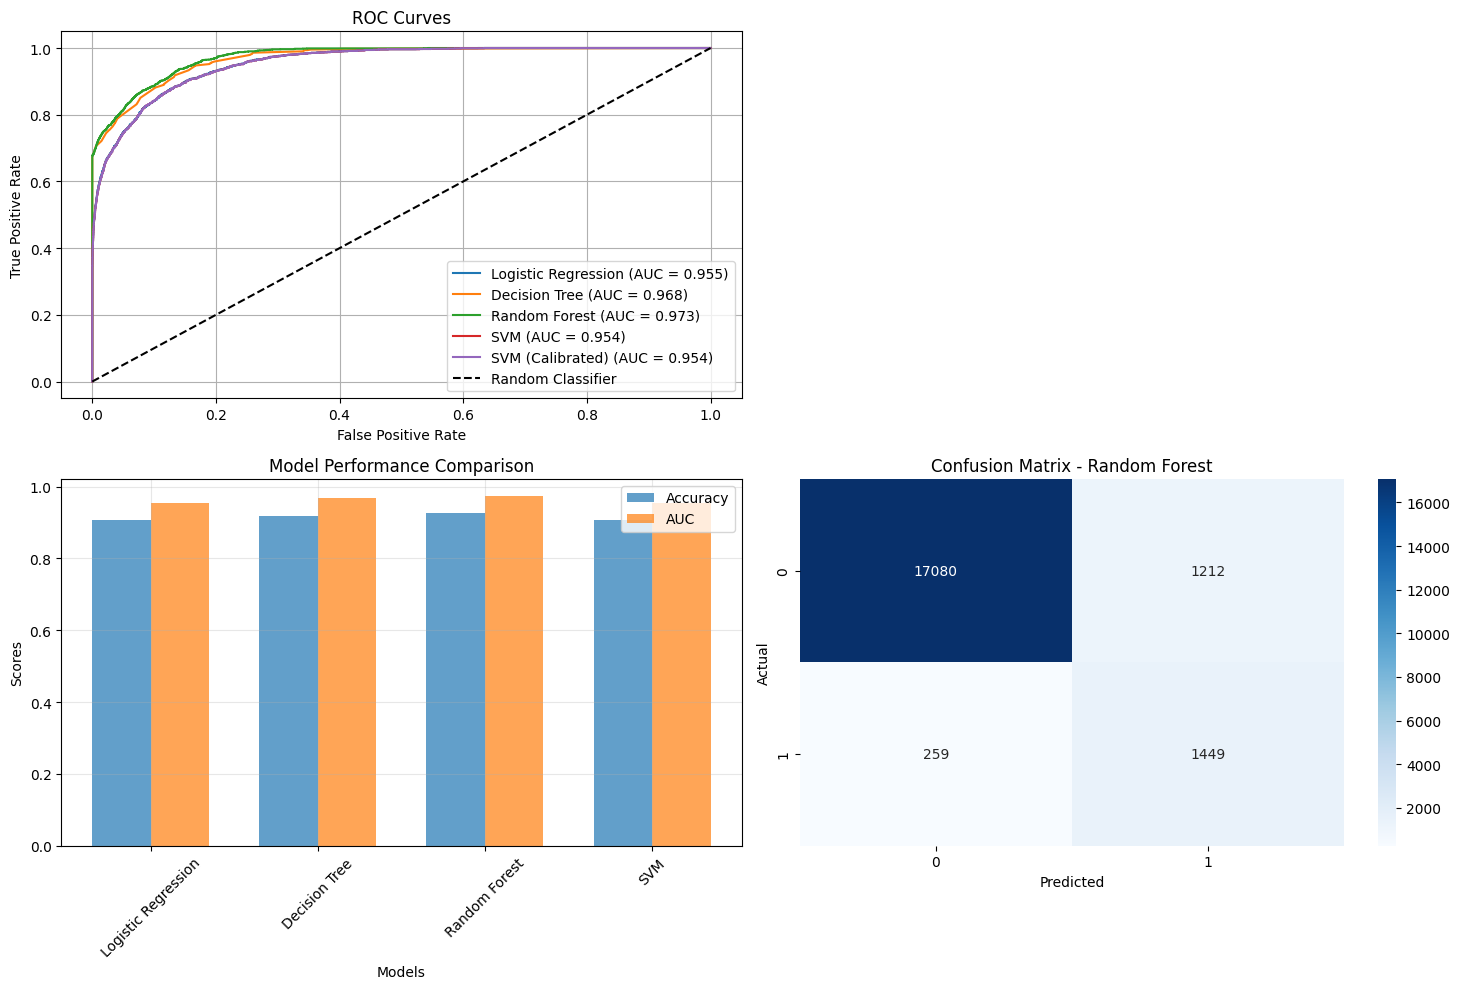


FINAL SUMMARY

Best Model: Random Forest
Best AUC: 0.9728
Best Accuracy: 0.9264

Detailed Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18292
           1       0.54      0.85      0.66      1708

    accuracy                           0.93     20000
   macro avg       0.76      0.89      0.81     20000
weighted avg       0.95      0.93      0.93     20000



In [55]:
print("COMPREHENSIVE MODEL COMPARISON\n")

results = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'auc': roc_auc_score(y_test, y_pred_proba_lr),
        'model': log_reg
    },
    'Decision Tree': {
        'accuracy': accuracy_score(y_test, y_pred_dt),
        'auc': roc_auc_score(y_test, y_pred_proba_dt),
        'model': dt_classifier
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'auc': roc_auc_score(y_test, y_pred_proba_rf),
        'model': rf_classifier
    },
    'SVM': {
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'auc': roc_auc_score(y_test, y_pred_proba_svm),
        'model' : svm_calibrated
    }
    }


comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results.keys()],
    'AUC': [results[model]['auc'] for model in results.keys()]
})

print(comparison_df.sort_values('AUC', ascending=False))

'''Visualization '''

plt.figure(figsize=(15, 10))

''' ROC Curves '''
plt.subplot(2, 2, 1)
for name, result in results.items():
    model = result['model']

    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif name == 'SVM' and 'svm_calibrated' in globals() and hasattr(svm_calibrated, 'predict_proba'):
         y_pred_proba = svm_calibrated.predict_proba(X_test)[:, 1]
    else:
        continue


    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["auc"]:.3f})')


if 'svm_calibrated' in globals():
     fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_calibrated.predict_proba(X_test)[:, 1])
     plt.plot(fpr_svm, tpr_svm, label=f'SVM (Calibrated) (AUC = {roc_auc_score(y_test, svm_calibrated.predict_proba(X_test)[:, 1]):.3f})')


plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)


''' Model Performance Comparison '''
plt.subplot(2, 2, 3)
models_plot = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models_plot]
auc_scores = [results[m]['auc'] for m in models_plot]

x = np.arange(len(models_plot))
width = 0.35

plt.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.7)
plt.bar(x + width/2, auc_scores, width, label='AUC', alpha=0.7)

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models_plot, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

''' Confusion Matrix for Best Model '''
plt.subplot(2, 2, 4)
best_model_name = comparison_df.loc[comparison_df['AUC'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f"\nFINAL SUMMARY\n")
print(f"Best Model: {best_model_name}")
print(f"Best AUC: {comparison_df['AUC'].max():.4f}")
print(f"Best Accuracy: {comparison_df['Accuracy'].max():.4f}")

print(f"\nDetailed Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best))